In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from transformers import pipeline

In [7]:
df = pd.read_csv("Womens Clothing E-Commerce Reviews.csv")

df.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Unnamed: 0               23486 non-null  int64
 1   Clothing ID              23486 non-null  int64
 2   Age                      23486 non-null  int64
 3   Title                    19676 non-null  str  
 4   Review Text              22641 non-null  str  
 5   Rating                   23486 non-null  int64
 6   Recommended IND          23486 non-null  int64
 7   Positive Feedback Count  23486 non-null  int64
 8   Division Name            23472 non-null  str  
 9   Department Name          23472 non-null  str  
 10  Class Name               23472 non-null  str  
dtypes: int64(6), str(5)
memory usage: 2.0 MB


In [9]:
df.columns

Index(['Unnamed: 0', 'Clothing ID', 'Age', 'Title', 'Review Text', 'Rating',
       'Recommended IND', 'Positive Feedback Count', 'Division Name',
       'Department Name', 'Class Name'],
      dtype='str')

In [10]:
df["Review Text"].isnull().sum()

np.int64(845)

In [11]:
df = df.dropna(subset=["Review Text"])

In [12]:
def clean_text(text):
    text = re.sub(r"<.*?>", "", text)      # HTML tags remove
    text = re.sub(r"[^a-zA-Z\s]", "", text) # Special characters remove
    text = re.sub(r"\s+", " ", text)        # Extra spaces remove
    return text.strip()

In [13]:
df["Clean_Review"] = df["Review Text"].apply(clean_text)

df[["Review Text", "Clean_Review"]].head()

,Review Text,Clean_Review
0,Absolutely wonderful - silky and sexy and comf...,Absolutely wonderful silky and sexy and comfor...
1,Love this dress! it's sooo pretty. i happene...,Love this dress its sooo pretty i happened to ...
2,I had such high hopes for this dress and reall...,I had such high hopes for this dress and reall...
3,"I love, love, love this jumpsuit. it's fun, fl...",I love love love this jumpsuit its fun flirty ...
4,This shirt is very flattering to all due to th...,This shirt is very flattering to all due to th...


In [14]:
import transformers
print(transformers.__version__)

5.14.1


In [15]:
from transformers import pipeline

In [2]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.13.0+cpu
False


In [16]:
import sys
print(sys.executable)

c:\Users\cc\Desktop\ProSensia Internship\venv\Scripts\python.exe


In [17]:
from transformers import pipeline
print("Transformers imported successfully!")

Transformers imported successfully!


In [4]:
classifier = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

print("Model Loaded Successfully!")

c:\Users\cc\Desktop\ProSensia Internship\venv\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\cc\.cache\huggingface\hub\models--distilbert-base-uncased-finetuned-sst-2-english. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 104/104 [00:00<00:00, 1048.77it/s]


Model Loaded Successfully!


In [18]:
sample_reviews = df["Clean_Review"].head(5).tolist()

results = classifier(sample_reviews)

results

[{'label': 'POSITIVE', 'score': 0.9998797178268433},
 {'label': 'POSITIVE', 'score': 0.9939841628074646},
 {'label': 'NEGATIVE', 'score': 0.7173237204551697},
 {'label': 'POSITIVE', 'score': 0.9998860359191895},
 {'label': 'POSITIVE', 'score': 0.9970471262931824}]

In [20]:
results = []

batch_size = 100

for i in range(0, len(df), batch_size):
    batch = df["Clean_Review"].iloc[i:i+batch_size].tolist()
    results.extend(classifier(batch))
    print(f"Processed {i + len(batch)} reviews")

Processed 100 reviews
Processed 200 reviews
Processed 300 reviews
Processed 400 reviews
Processed 500 reviews
Processed 600 reviews
Processed 700 reviews
Processed 800 reviews
Processed 900 reviews
Processed 1000 reviews
Processed 1100 reviews
Processed 1200 reviews
Processed 1300 reviews
Processed 1400 reviews
Processed 1500 reviews
Processed 1600 reviews
Processed 1700 reviews
Processed 1800 reviews
Processed 1900 reviews
Processed 2000 reviews
Processed 2100 reviews
Processed 2200 reviews
Processed 2300 reviews
Processed 2400 reviews
Processed 2500 reviews
Processed 2600 reviews
Processed 2700 reviews
Processed 2800 reviews
Processed 2900 reviews
Processed 3000 reviews
Processed 3100 reviews
Processed 3200 reviews
Processed 3300 reviews
Processed 3400 reviews
Processed 3500 reviews
Processed 3600 reviews
Processed 3700 reviews
Processed 3800 reviews
Processed 3900 reviews
Processed 4000 reviews
Processed 4100 reviews
Processed 4200 reviews
Processed 4300 reviews
Processed 4400 revie

In [21]:
df["Predicted_Sentiment"] = [result["label"] for result in results]
df["Confidence_Score"] = [result["score"] for result in results]

df.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name,Clean_Review,Predicted_Sentiment,Confidence_Score
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates,Absolutely wonderful silky and sexy and comfor...,POSITIVE,0.999880
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses,Love this dress its sooo pretty i happened to ...,POSITIVE,0.993984
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,I had such high hopes for this dress and reall...,NEGATIVE,0.717324
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants,I love love love this jumpsuit its fun flirty ...,POSITIVE,0.999886
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses,This shirt is very flattering to all due to th...,POSITIVE,0.997047


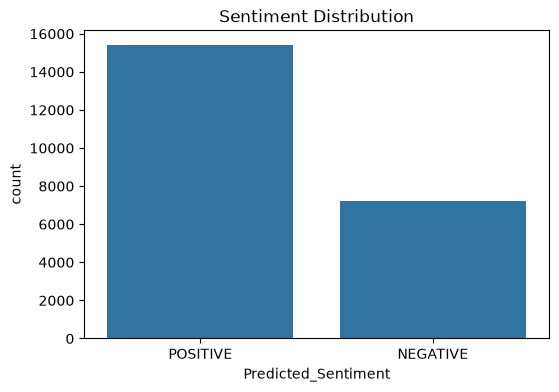

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Predicted_Sentiment")
plt.title("Sentiment Distribution")
plt.show()

In [23]:
df.to_csv("customer_reviews_with_sentiment.csv", index=False)

In [25]:
df.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name,Clean_Review,Predicted_Sentiment,Confidence_Score
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates,Absolutely wonderful silky and sexy and comfor...,POSITIVE,0.999880
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses,Love this dress its sooo pretty i happened to ...,POSITIVE,0.993984
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,I had such high hopes for this dress and reall...,NEGATIVE,0.717324
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants,I love love love this jumpsuit its fun flirty ...,POSITIVE,0.999886
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses,This shirt is very flattering to all due to th...,POSITIVE,0.997047


## Conclusion

- Customer reviews were cleaned using Regular Expressions.
- A pre-trained Hugging Face sentiment analysis model was used.
- Each review was classified into a sentiment category with a confidence score.
- The sentiment distribution was visualized using a count plot.
- The final dataset was exported successfully.